In [1]:
from LIMxCMBL.kernels import *
from LIMxCMBL.experiments import *

/home/users/delon/.local/lib/python3.9/site-packages/astropy/units/quantity.py:673: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [2]:
import matplotlib.pyplot as plt

In [3]:
dchi = np.mean(np.diff(chis))

In [4]:
kernels = {}
kernels['CII'] = np.array(KI)
kernels['CO'] = np.array(KI_CO)
kernels['Lya'] = np.array(KI_Lya)
kernels['HI'] = np.array(KI_HI)

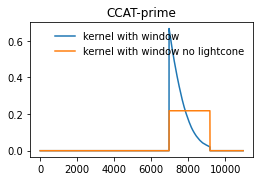

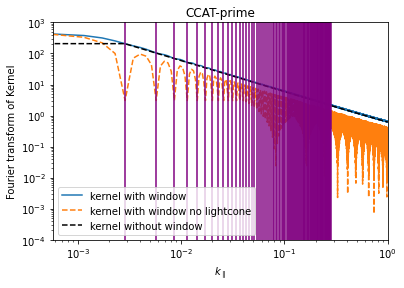

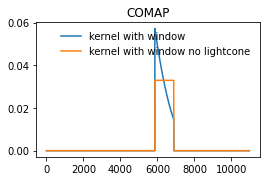

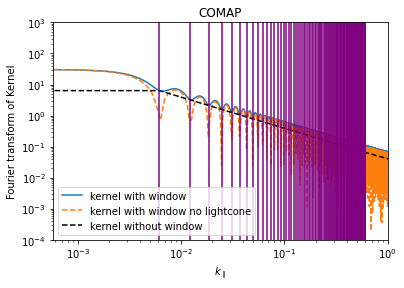

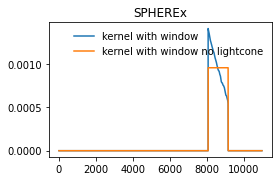

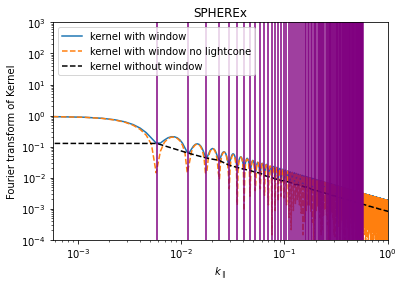

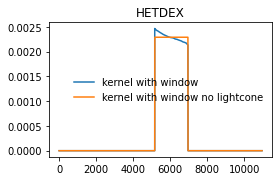

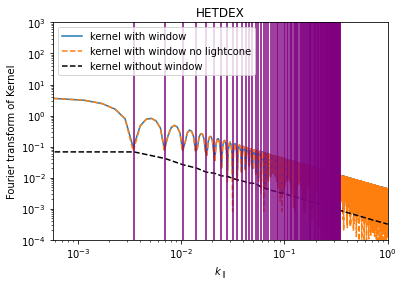

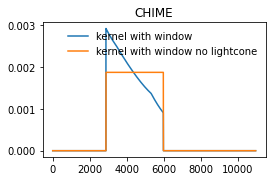

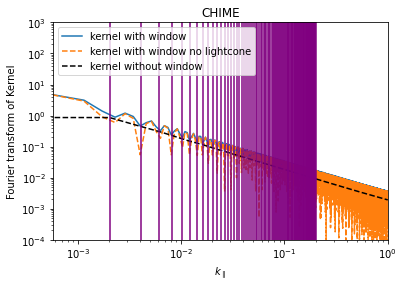

In [5]:
for experiment in experiments:
    zmin = experiments[experiment]['zmin']
    zmax = experiments[experiment]['zmax']
    line_str = experiments[experiment]['line_str']

    chimin = ccl.comoving_angular_distance(cosmo, 1/(1+zmin))
    chimax = ccl.comoving_angular_distance(cosmo, 1/(1+zmax))
    
    idx_window = np.where((chis >= chimin) & (chis <= chimax))
    window = np.zeros_like(chis)
    window[idx_window] = 1
    
    unwindowedKI = kernels[line_str]
    
    
    kernel_with_window = unwindowedKI * window
    kernel_with_window_k = np.fft.fft(kernel_with_window)

    ks0 = 2*np.pi*np.fft.fftfreq(len(chis), d=dchi)
    sidx0 = np.argsort(ks0)
    
    kernel_with_window_mean = np.mean(unwindowedKI[idx_window]) * window
    kernel_with_window_mean_k = np.fft.fft(kernel_with_window_mean)
    
    
    kernel_without_window = unwindowedKI[idx_window]
    kernel_without_window_k = np.fft.fft(kernel_without_window)
    
#     analytical = 

    ks1 = 2*np.pi*np.fft.fftfreq(len(kernel_without_window), d=dchi)
    sidx1 = np.argsort(ks1)
    

    kernel_without_window_mean = np.mean(unwindowedKI[idx_window]) * np.ones_like(kernel_without_window)
    kernel_without_window_mean_k = np.fft.fft(kernel_without_window_mean)

    plt.figure(figsize=(4,4/1.618))
    plt.plot(chis, kernel_with_window, label='kernel with window')
    plt.plot(chis, kernel_with_window_mean, label='kernel with window no lightcone')
    plt.legend(frameon=False)
    plt.title(experiment)
    plt.show()
    
    
    
    plt.plot(ks0[sidx0], np.abs(kernel_with_window_k)[sidx0], label='kernel with window')

    plt.plot(ks0[sidx0], np.abs(kernel_with_window_mean_k)[sidx0], label='kernel with window no lightcone', ls='--')
    plt.plot(ks1[sidx1], np.abs(kernel_without_window_k)[sidx1], label='kernel without window', ls='--', c='k')

    plt.xscale('log')
    plt.yscale('log')
    plt.xlim(2*np.pi/chimax_sample, 1e0)
    plt.ylim(1e-4, 1e3)
    for i in range(1, 100):
        plt.axvline(i*2*np.pi/(chimax-chimin), c='purple')

    plt.legend()
    plt.title(experiment)
    plt.ylabel('Fourier transform of Kernel')
    plt.xlabel(r'$k_\parallel$')
    plt.show()

CCAT-prime 36
2209.537953658859

COMAP 17
1022.0324801088227

SPHEREx 18
1080.743944108328

HETDEX 29
1794.4923191452344

CHIME 50
3102.1650835298765



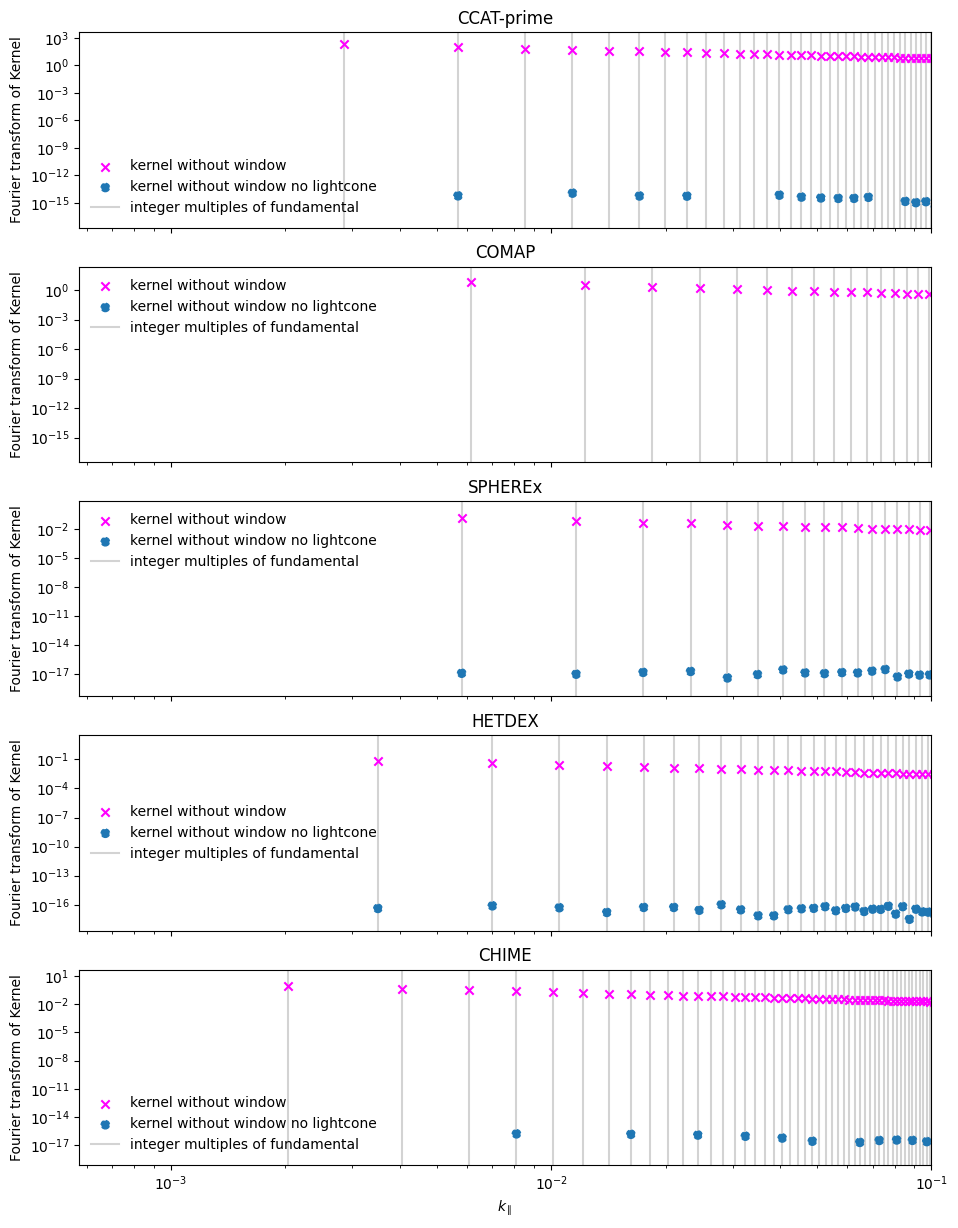

In [6]:
fig, axs = plt.subplots(nrows=5, ncols=1, dpi=100, figsize=(11,3*5), sharex=True, facecolor='w')

ax_i = 0
for experiment in experiments:
    ax = axs[ax_i]
    zmin = experiments[experiment]['zmin']
    zmax = experiments[experiment]['zmax']
    line_str = experiments[experiment]['line_str']

    chimin = ccl.comoving_angular_distance(cosmo, 1/(1+zmin))
    chimax = ccl.comoving_angular_distance(cosmo, 1/(1+zmax))
    
    idx_window = np.where((chis >= chimin) & (chis <= chimax))
    window = np.zeros_like(chis)
    window[idx_window] = 1
    
    unwindowedKI = kernels[line_str]
    
    
    kernel_with_window = unwindowedKI * window
    kernel_with_window_k = np.fft.fft(kernel_with_window)

    ks0 = 2*np.pi*np.fft.fftfreq(len(chis), d=dchi)
    sidx0 = np.argsort(ks0)
    
    kernel_with_window_mean = np.mean(unwindowedKI[idx_window]) * window
    kernel_with_window_mean_k = np.fft.fft(kernel_with_window_mean)
    
    
    kernel_without_window = unwindowedKI[idx_window]
    kernel_without_window_k = np.fft.fft(kernel_without_window)
    

    ks1 = 2*np.pi*np.fft.fftfreq(len(kernel_without_window), d=dchi)
    sidx1 = np.argsort(ks1)
    

    kernel_without_window_mean = np.mean(unwindowedKI[idx_window]) * np.ones_like(kernel_without_window)
    kernel_without_window_mean_k = np.fft.fft(kernel_without_window_mean)
    
    ax.scatter(ks1[sidx1], np.abs(kernel_without_window_k)[sidx1], label='kernel without window', c='magenta',
                marker='x')
#     ax.scatter(ks0[sidx0], np.abs(kernel_with_window_k)[sidx0], label='kernel with window', c='cyan',
#                 marker='+')

#     ax.scatter(ks0[sidx0], np.abs(kernel_with_window_mean_k)[sidx0], label='kernel with window no lightcone', ls='--')
    ax.scatter(ks1[sidx1], np.abs(kernel_without_window_mean_k)[sidx1], label='kernel without window no lightcone', ls='--')

    plt.xlim(2*np.pi/chimax_sample, 1e-1)
#     plt.ylim(1e-4, 1e3)
    for i in range(1, 100):
        if(i==1):
            ax.axvline(i*2*np.pi/(chimax-chimin), c='lightgrey', zorder=-1, label='integer multiples of fundamental')
        else:
            ax.axvline(i*2*np.pi/(chimax-chimin), c='lightgrey', zorder=-1)
            
        if(i * 2 * np.pi / (chimax - chimin) > 0.1):
            print(experiment, i)
            print(chimax-chimin)
            print()
            break
    ax.set_yscale('log')

    ax.legend(frameon=False)
    ax.set_title(experiment)
    ax.set_ylabel('Fourier transform of Kernel')
    ax_i += 1
# axs[-1].set_xlim(0, None)
axs[-1].set_xlabel(r'$k_\parallel$')
axs[-1].set_xscale('log')


In [7]:
~np.array([True, False])

array([False,  True])

In [8]:
# def lo_DFT(alpha, chimin, chimax, m):
#     _L = chimax - chimin
    
#     return np.where(
#         np.abs((np.abs(alpha)-_L) / _L) < 0.0001,
#         (2 * (1 + m) / _L**2
#          *( _L * np.cos(2 * m * np.pi) 
#            + m * np.pi * (_L - alpha) * np.sin(2 * m * np.pi)
#           )
#          - 1 / _L
#         ),
#         np.sin(np.pi/_L * alpha * (1 + 2 * m)) / np.sin(np.pi/_L * alpha) * 1/_L
#     )


def lo_DFT(alpha, chimin, chimax, m):
    _L = chimax - chimin
    return np.where(
        (np.abs((np.abs(alpha)-_L) / _L) < 0.001) | (np.abs(alpha / _L) < 0.001),
        (1 + 2 * m) / _L,
        np.sin(np.pi/_L * alpha * (1 + 2 * m)) / np.sin(np.pi/_L * alpha) * 1/_L
    )

In [9]:
def asdf(    LPOW = -1):
    fig, axs = plt.subplots(nrows=5, ncols=1, dpi=100, figsize=(11,3*5), facecolor='w')

    ax_i = 0
    for experiment in experiments:
        ax = axs[ax_i]
        zmin = experiments[experiment]['zmin']
        zmax = experiments[experiment]['zmax']
        line_str = experiments[experiment]['line_str']

        chimin = ccl.comoving_angular_distance(cosmo, 1/(1+zmin))
        chimax = ccl.comoving_angular_distance(cosmo, 1/(1+zmax))
        _L = chimax - chimin
        alphas = np.linspace(-_L, _L, 10001)
                
        for i in range(1, 100):
            if(i * 2 * np.pi / _L > 10**(LPOW)):
                ax.plot(alphas, 
                        lo_DFT(
                            alphas,
                            chimin = chimin, 
                            chimax = chimax, 
                            m=i
                        ), 
                        label=r'$\Lambda = 10^{%.2f},\ m=%d$'%(LPOW,i), c='cyan')

                ax.plot(alphas, 10**(LPOW) / np.pi * np.sinc(10**(LPOW) * alphas / np.pi), c='magenta', 
                        ls='--', label='orig sinc (not DFT)$\Lambda = 10^{%.2f}$'%(LPOW))
                break


        ax.legend(frameon=False)
        ax.set_title(experiment)
        ax.set_xticks([])
        ax_i += 1
        
        print(experiment, 2*np.pi/_L * 10)

    axs[-1].set_xlabel(r"$\chi-\chi'$")


/tmp/ipykernel_13139/2541863799.py:21: RuntimeWarning: invalid value encountered in divide
  np.sin(np.pi/_L * alpha * (1 + 2 * m)) / np.sin(np.pi/_L * alpha) * 1/_L


CCAT-prime 0.028436648018537167
COMAP 0.06147735448202755
SPHEREx 0.0581375943990466
HETDEX 0.03501372081755379
CHIME 0.02025419388716124


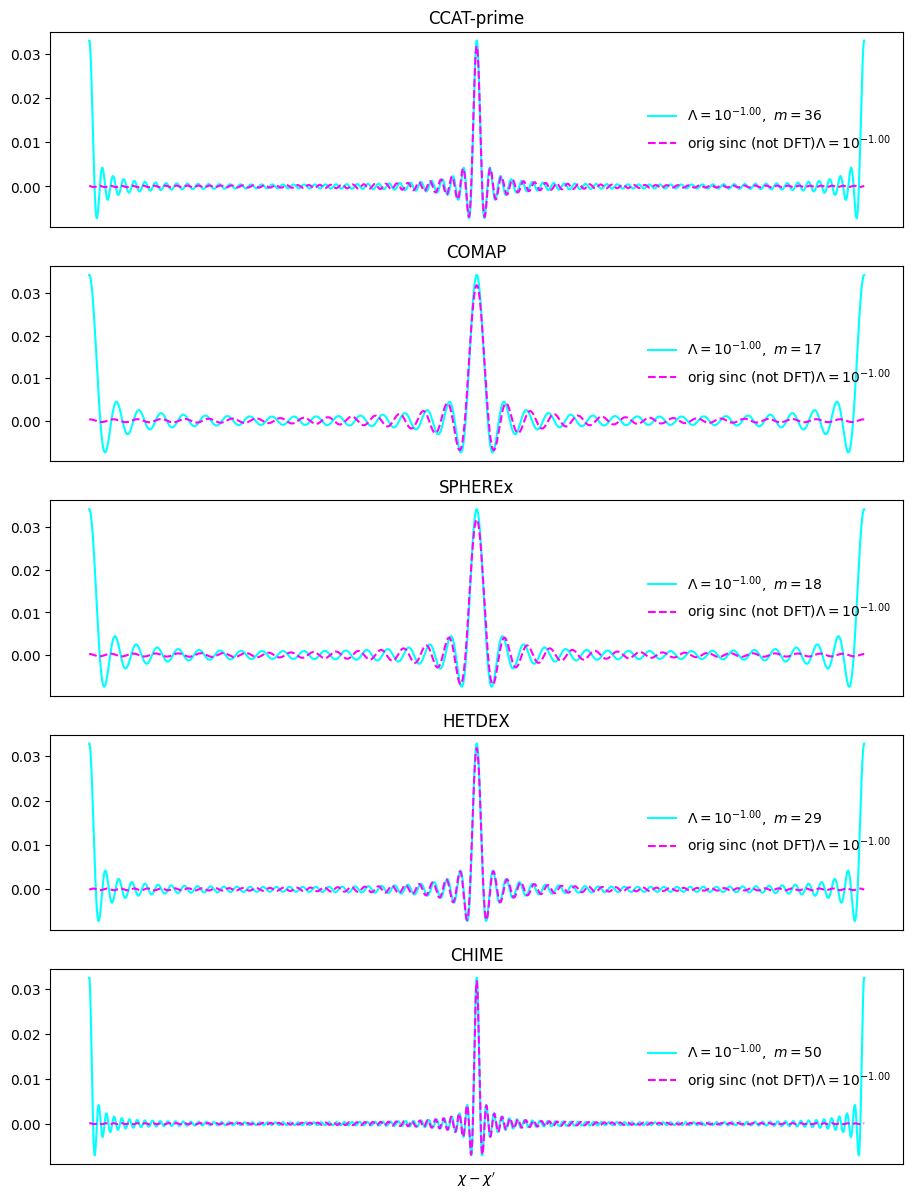

In [10]:
asdf(-1)

/tmp/ipykernel_13139/2541863799.py:21: RuntimeWarning: invalid value encountered in divide
  np.sin(np.pi/_L * alpha * (1 + 2 * m)) / np.sin(np.pi/_L * alpha) * 1/_L


CCAT-prime 0.028436648018537167
COMAP 0.06147735448202755
SPHEREx 0.0581375943990466
HETDEX 0.03501372081755379
CHIME 0.02025419388716124


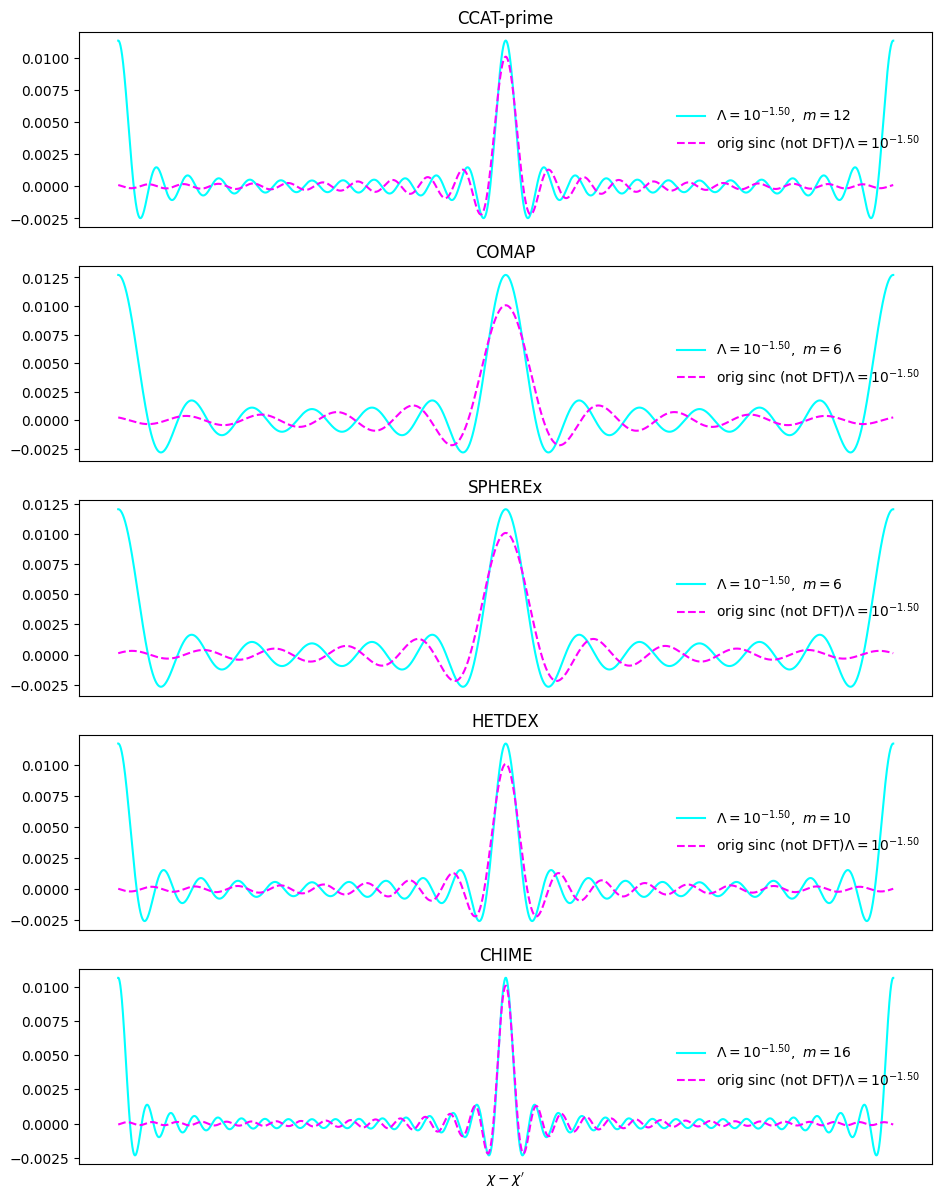

In [11]:
asdf(np.log10(Lambdas[21]))

/tmp/ipykernel_13139/2541863799.py:21: RuntimeWarning: invalid value encountered in divide
  np.sin(np.pi/_L * alpha * (1 + 2 * m)) / np.sin(np.pi/_L * alpha) * 1/_L


CCAT-prime 0.028436648018537167
COMAP 0.06147735448202755
SPHEREx 0.0581375943990466
HETDEX 0.03501372081755379
CHIME 0.02025419388716124


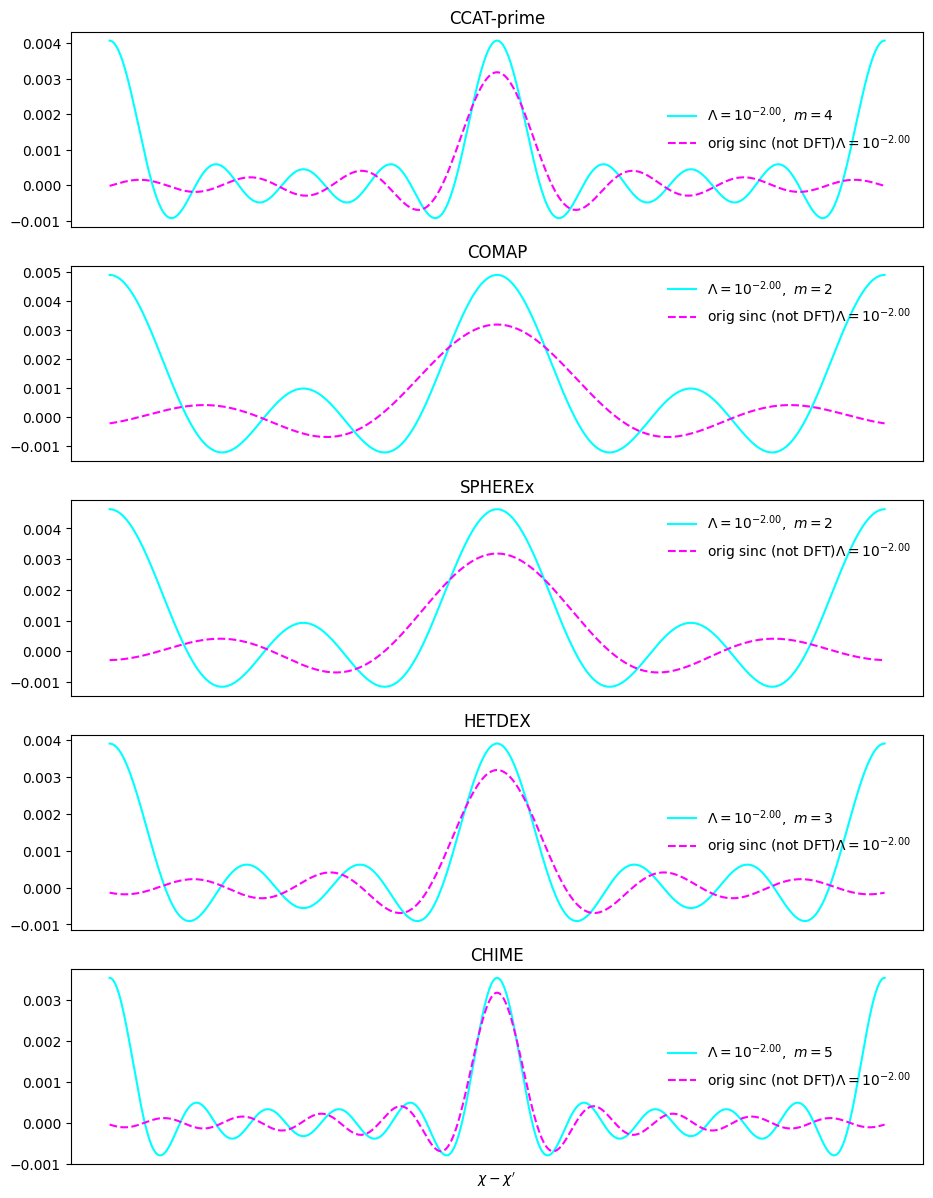

In [12]:
asdf(-2)

putting in superlinear_evol


(0.1, 1.1)

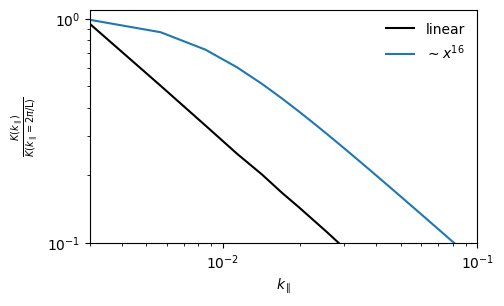

In [40]:
fig, ax = plt.subplots(nrows=1, ncols=1, dpi=100, figsize=(5, 5/1.618), sharex=True, facecolor='w')

ax_i = 0
for experiment in experiments:
    zmin = experiments[experiment]['zmin']
    zmax = experiments[experiment]['zmax']
    line_str = experiments[experiment]['line_str']

    chimin = ccl.comoving_angular_distance(cosmo, 1/(1+zmin))
    chimax = ccl.comoving_angular_distance(cosmo, 1/(1+zmax))
    
    idx_window = np.where((chis >= chimin) & (chis <= chimax))
    window = np.zeros_like(chis)
    window[idx_window] = 1
    
    ### SUP LIN from 009.016
    tmp_idxs = np.where((chis >= chimin) & (chis <= chimax))
    print('putting in superlinear_evol')
    
    mean_KI = np.mean(kernels[line_str][tmp_idxs])
    
    #constraints
    #supLin(chimax) = 0
    #1/L int_chimin^chimax supLin(chi) = mean_KI
    
#     _a = (5 * mean_KI)**(1/4)/(chimax - chimin)
#     _b = (5 * mean_KI)**(1/4) * chimax / (chimax - chimin)
#     _supLin_KI = (_a * chis - _b)**4
    
    
    _a = 17 * mean_KI * chimax / (chimax - chimin)**(17)
    _supLin_KI = _a * (chis - chimax)**16

    supLin_kernel_without_window = _supLin_KI[tmp_idxs]
    supLin_kernel_without_window_k = np.fft.rfft(supLin_kernel_without_window)
    ###########################

    unwindowedKI = kernels[line_str]
    
    
    kernel_without_window = unwindowedKI[idx_window]
    kernel_without_window_k = np.fft.rfft(kernel_without_window)
    ks1 = 2*np.pi*np.fft.rfftfreq(len(kernel_without_window), d=dchi)
    
    plt.plot(ks1, np.abs(kernel_without_window_k/kernel_without_window_k[1]), c='k', label='linear')
#     plt.scatter(ks1, np.abs(kernel_without_window_k/kernel_without_window_k[1]))
    
    plt.plot(ks1, np.abs(supLin_kernel_without_window_k/supLin_kernel_without_window_k[1]), label=r'$\sim x^{16}$')

    ax.set_yscale('log')

    ax.legend(frameon=False)
    ax.set_ylabel(r'$\frac{K(k_\parallel)}{K(k_\parallel=2\pi/{\sf L})}$')
    ax_i += 1
    break
    
    
ax.set_xlim(3e-3, 1e-1)
ax.set_xlabel(r'$k_\parallel$')
ax.set_xscale('log')

ax.set_ylim(0.1, 1.1)